# A first look at your results

Run this after the demo finishes. It opens the tables the pipeline wrote, shows how they fit
together, and makes the plots worth checking first.

Nothing here loads the big mask volumes, so it runs in a few seconds.

In [1]:
# cell 1
import sys
from pathlib import Path

try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from tifffile import imread
except ModuleNotFoundError as missing:
    # Two different causes, and the message must not guess between them. Either
    # EASI-PASS was never installed into this environment, or Jupyter picked a
    # different one: it searches ~/.local/share/jupyter/kernels before an
    # environment's own kernels, so a leftover kernel can shadow the right one.
    raise SystemExit(
        f"'{missing.name}' is not installed in the Python running this notebook:\n"
        f"  {sys.executable}\n\n"
        "Either EASI-PASS is not installed there, in which case, from the repo\n"
        "with that environment active:\n"
        "  pip install -e . -c requirements.txt\n\n"
        "Or the notebook is on a different environment than you expect. Compare\n"
        "the path above with the one you installed into, and if they differ use\n"
        "Kernel > Change Kernel to switch.\n"
    ) from None

# Point this at any finished OUTPUT folder. The default is the demo run.
OUTPUT = Path("demo_pre_run/JS078_demo/OUTPUT")
if not OUTPUT.exists():
    OUTPUT = Path("demo") / OUTPUT          # if the notebook is run from the repo root
PLANE = "0"

assert OUTPUT.exists(), f"No OUTPUT folder at {OUTPUT.resolve()} - edit the path above"
print("reading", OUTPUT)          # relative, so a saved notebook carries no local paths

reading demo_pre_run\JS078_demo\OUTPUT


## 1. The main table

One row per cell in the reference FISH round. The gene columns hold that cell's intensity per
channel; the `twoP_` columns say which functional cell it turned out to be.

In [2]:
# cell 2
merged = pd.read_csv(OUTPUT / f"MERGED/aligned_extracted_features/full_table_mean_twop_plane{PLANE}.csv")

print(f"{len(merged)} FISH cells x {len(merged.columns)} columns\n")
print("columns:", list(merged.columns))

genes = [g for g in merged.columns if g.startswith("mean_round_")]
merged.head(3)

21081 FISH cells x 11 columns

columns: ['mask_id_main', 'mean_round_01_DAPI', 'mean_round_01_GCAMP', 'mean_round_01_PV', 'mean_round_01_SST', 'mean_round_01_TDTOMATO', 'twoP_iou_match', 'twoP_iou', 'twoP_somaprint_match', 'twoP_somaprint_confident', 'plane']


,mask_id_main,mean_round_01_DAPI,mean_round_01_GCAMP,mean_round_01_PV,mean_round_01_SST,mean_round_01_TDTOMATO,twoP_iou_match,twoP_iou,twoP_somaprint_match,twoP_somaprint_confident,plane
0,1,12.307564,4.940763,0.009705,0.000335,1.090361,NaN,NaN,NaN,False,0
1,2,9.476904,2.074906,0.013733,0.001248,0.997503,NaN,NaN,NaN,False,0
2,3,7.267290,0.450467,0.000000,0.000000,1.450467,NaN,NaN,NaN,False,0


## 2. Two matchers, reported separately

Mask overlap and soma-print are worked out independently and never reconciled, so you can see
where they agree and set your own threshold. `twoP_somaprint_confident` is always True or
False, never blank: a pick that did not clear its gate is still recorded.

matched by overlap only      176
matched by both             1036
matched by soma-print only   124
not matched                19745   (mostly cells outside the imaged field)

Where both spoke, they named the same cell 1020/1036 times (98.5%)


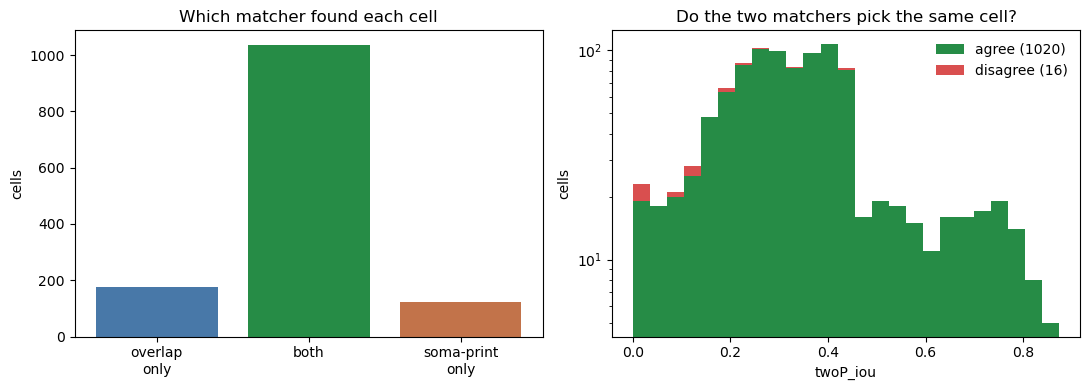

In [3]:
# cell 3
by_iou  = merged.twoP_iou_match.notna()
by_soma = merged.twoP_somaprint_confident.fillna(False).astype(bool)

both = merged[by_iou & by_soma]
agree = both.twoP_iou_match == both.twoP_somaprint_match

print(f"matched by overlap only    {int((by_iou & ~by_soma).sum()):>5}")
print(f"matched by both            {int((by_iou &  by_soma).sum()):>5}")
print(f"matched by soma-print only {int((~by_iou & by_soma).sum()):>5}")
print(f"not matched                {int((~by_iou & ~by_soma).sum()):>5}   (mostly cells outside the imaged field)")
print(f"\nWhere both spoke, they named the same cell {agree.sum()}/{len(both)} times ({100*agree.mean():.1f}%)")

fig, (a, b) = plt.subplots(1, 2, figsize=(11, 4))

a.bar(["overlap\nonly", "both", "soma-print\nonly"],
      [int((by_iou & ~by_soma).sum()), int((by_iou & by_soma).sum()), int((~by_iou & by_soma).sum())],
      color=["#4878a8", "#268c46", "#c2734a"])
a.set_ylabel("cells"); a.set_title("Which matcher found each cell")

# Disagreements cluster at low overlap, which is what you would hope: the two
# methods part company exactly where the overlap evidence is weakest.
b.hist([both.twoP_iou[agree], both.twoP_iou[~agree]], bins=25, stacked=True,
       color=["#268c46", "#d94f4f"], label=[f"agree ({agree.sum()})", f"disagree ({(~agree).sum()})"])
b.set_xlabel("twoP_iou"); b.set_ylabel("cells"); b.set_yscale("log")
b.set_title("Do the two matchers pick the same cell?"); b.legend(frameon=False)
plt.tight_layout()

## 3. Adding positions

The main table has no coordinates. Cell centroids live in the intensity table, which is long
format: one row per cell per channel. Join on `mask_id` to place every cell.

In [4]:
# cell 4
inten = pd.read_csv(next((OUTPUT / "HCR/extract_intensities").glob("*_probs_intensities.csv")))
pos = inten.groupby("mask_id")[["X", "Y", "Z"]].first()

df = merged.merge(pos, left_on="mask_id_main", right_index=True, how="left")
print(f"{df.X.notna().sum()}/{len(df)} cells placed")
df[["mask_id_main", "X", "Y", "Z", "twoP_iou_match"]].head(3)

21081/21081 cells placed


,mask_id_main,X,Y,Z,twoP_iou_match
0,1,106.471888,10.312584,3.395917,NaN
1,2,828.474407,4.598002,1.354557,NaN
2,3,1046.456075,3.971963,0.945794,NaN


## 4. Did the alignment work?

The clearest check. Every functional cell, coloured by whether it found a partner in the FISH
volume. Unmatched cells scattered evenly is normal; a whole region of red means the alignment
missed there.

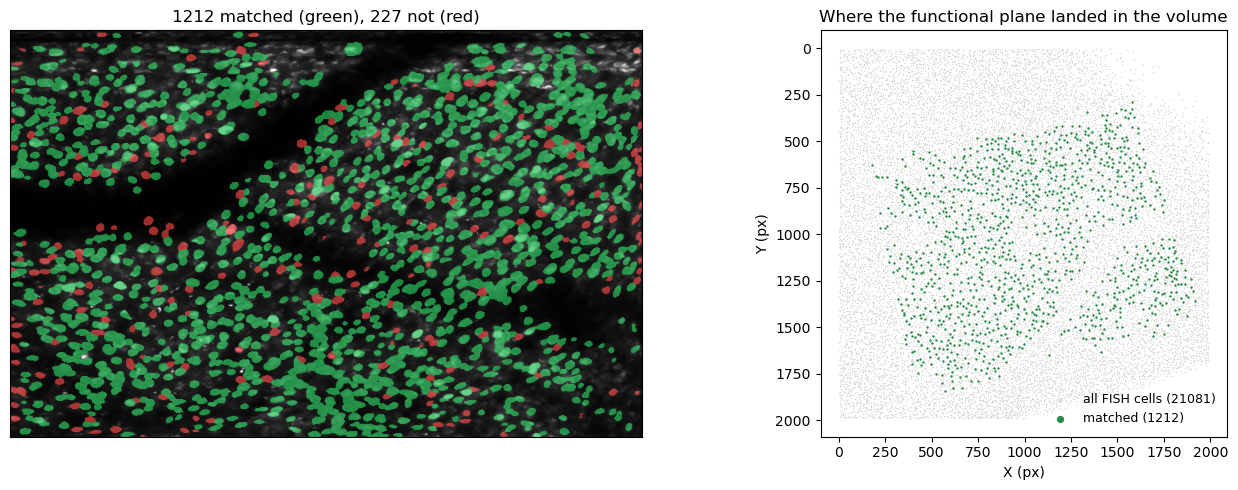

In [5]:
# cell 5
mean_img = imread(OUTPUT / f"2P/cellpose/lowres_meanImg_C0_plane{PLANE}.tiff").astype(float)
masks_2p = imread(OUTPUT / f"2P/cellpose/lowres_meanImg_C0_plane{PLANE}_masks.tiff")

matched_ids = set(merged.twoP_iou_match.dropna().astype(int))
lut = np.zeros((int(masks_2p.max()) + 1, 4))
lut[np.isin(np.arange(len(lut)), list(matched_ids))] = [0.15, 0.75, 0.35, 0.7]
lut[[i for i in range(len(lut)) if i not in matched_ids]] = [0.90, 0.25, 0.25, 0.7]
lut[0] = 0

fig, (a, b) = plt.subplots(1, 2, figsize=(14, 5))
lo, hi = np.percentile(mean_img, [1, 99.5])
a.imshow(np.clip((mean_img - lo) / (hi - lo), 0, 1), cmap="gray")
a.imshow(lut[masks_2p]); a.set_xticks([]); a.set_yticks([])
a.set_title(f"{len(matched_ids)} matched (green), {int(masks_2p.max()) - len(matched_ids)} not (red)")

b.scatter(df.X, df.Y, s=1, c="0.85", linewidths=0, label=f"all FISH cells ({len(df)})")
b.scatter(df.X[by_iou], df.Y[by_iou], s=3, c="#268c46", linewidths=0, label=f"matched ({by_iou.sum()})")
b.set_aspect("equal"); b.invert_yaxis(); b.set_xlabel("X (px)"); b.set_ylabel("Y (px)")
b.set_title("Where the functional plane landed in the volume")
b.legend(frameon=False, markerscale=3, fontsize=9)
plt.tight_layout()

## 5. Each probe, in the cells you recorded from

Cell centroids, coloured by expression, for the cells that matched a functional cell. Each
probe is scaled to its own 5th-95th percentile so channels of very different brightness stay
comparable, and every FISH cell is drawn faint underneath for context.

DAPI is skipped (a nuclear stain, present in every round, says nothing about cell type) and so
is GCAMP (it reports the functional indicator, not cell identity).

The FISH mask volume is still read here because the next section needs it, so give it about
fifteen seconds.

In [ ]:
# cell 6
from tifffile import imread as _imread

hcr_ref = sorted((OUTPUT / "HCR" / "cellpose").glob("HCR*_masks.tiff"))[0]
hcr_3d = _imread(hcr_ref)                        # kept, the next cell needs the z axis

matched_cells = df[by_soma]
probes = [g for g in genes if not any(s in g.upper() for s in ("DAPI", "GCAMP"))]
print(f"{len(matched_cells)} soma-print matched cells, {len(probes)} probes")

fig, axes = plt.subplots(1, len(probes), figsize=(5.2 * len(probes), 5.4), squeeze=False)
for ax, gene in zip(axes.ravel(), probes):
    v = matched_cells[gene].to_numpy()
    lo, hi = np.nanpercentile(v, [5, 95])
    # A sparse probe can have its 5th AND 95th percentile at zero, which would
    # collapse the scale and render the panel blank. Fall back to the full range
    # so the few positive cells still show.
    if hi - lo < 1e-9:
        lo, hi = 0.0, float(np.nanmax(v))

    # Centroids, not painted mask shapes. A soma is a few pixels across at this
    # zoom, so the outline carries nothing the dot does not, and painting shapes
    # put every cell at equal visual weight -- a dim cell with a large mask read
    # louder than a bright cell with a small one. Faint grey underneath is every
    # FISH cell, so the matched subset is read against the whole field.
    ax.scatter(df.X, df.Y, s=1.5, c="0.88", linewidths=0)
    order = np.argsort(np.nan_to_num(v))          # dim first, so bright lands on top
    sc = ax.scatter(matched_cells.X.to_numpy()[order],
                    matched_cells.Y.to_numpy()[order],
                    c=np.clip(v[order], lo, hi), s=14, cmap="viridis",
                    vmin=lo, vmax=hi, linewidths=0)
    ax.set_aspect("equal"); ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(gene.replace("mean_round_", "round "), fontsize=11)
    plt.colorbar(sc, ax=ax, fraction=0.046, label="5th-95th pct")
plt.tight_layout()

## 6. The matched masks, overlaid

Every soma-print-matched pair in the plane, drawn together. **Green is a functional cell,
magenta is its EASI-FISH partner, and white is where the two overlap** — so a well-registered
plane is mostly white, with coloured fringes where the two outlines disagree.

The FISH volume is sampled on the surface the functional sheet actually sits on, not flattened
through z, so the two masks are compared where they genuinely meet.

Text(0.5, 0.02, 'green = functional     magenta = EASI-FISH     white = overlap')

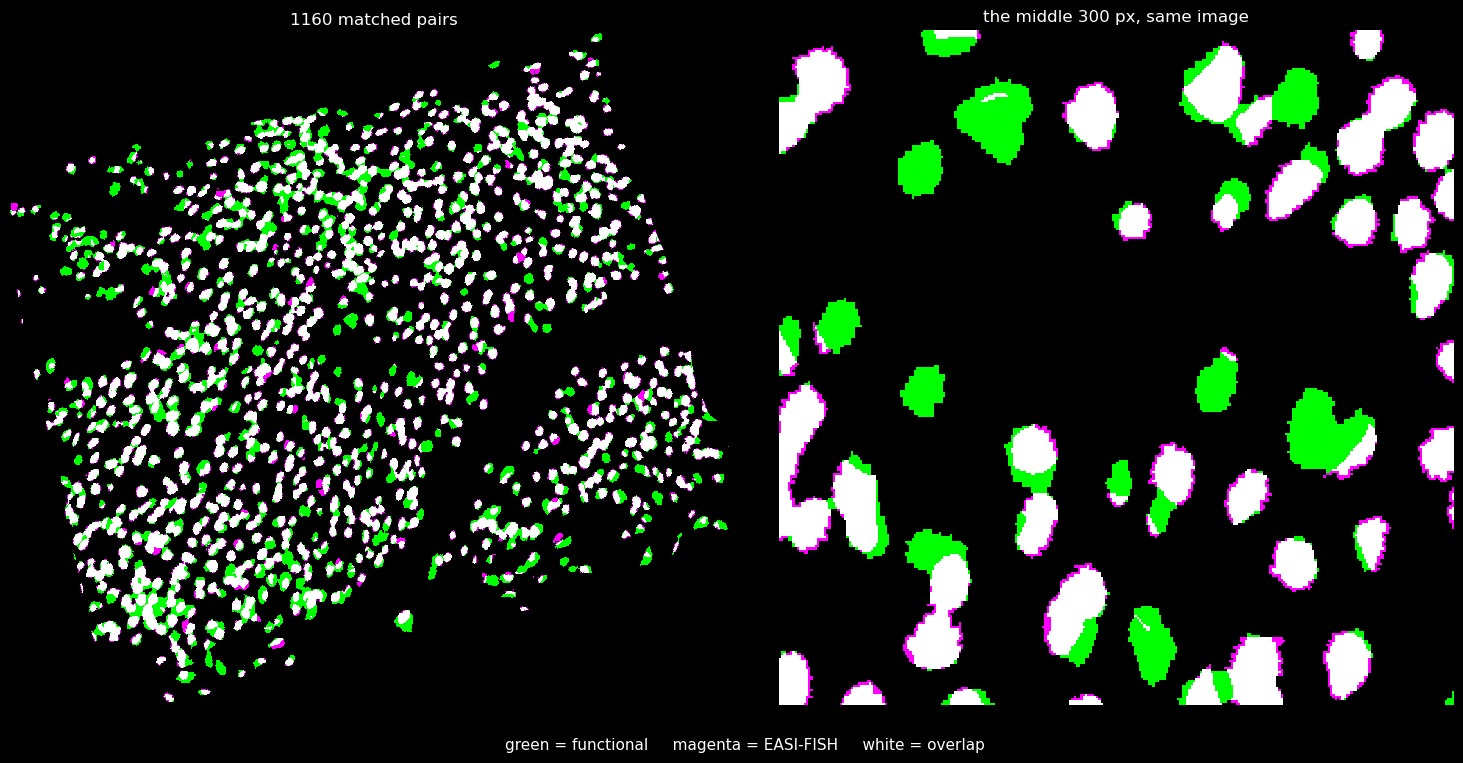

In [7]:
# cell 7
from scipy.ndimage import binary_erosion

# The 2P volume is a 2D sheet draped through 3D: exactly one non-zero z per (y, x).
# So its argmax over z IS the z-map, the surface the functional plane occupies in
# the FISH volume, and sampling the FISH masks on that surface compares the two
# where they actually meet. Flattening FISH through z instead would pile cells
# from every depth on top of each other.
twop_3d = _imread(OUTPUT / f"2P/registered/twop_plane{PLANE}_aligned_3d.tiff")
twop_lbl = twop_3d.max(axis=0)
zmap = twop_3d.argmax(axis=0)
del twop_3d

yy, xx = np.mgrid[0:zmap.shape[0], 0:zmap.shape[1]]
hcr_lbl = hcr_3d[zmap, yy, xx]
del hcr_3d

# Paired cells only: each side keeps just the labels soma-print matched.
paired = df[by_soma]
keep_2p = set(paired.twoP_somaprint_match.dropna().astype(int))
keep_hcr = set(paired.mask_id_main.astype(int))
tp = np.isin(twop_lbl, list(keep_2p))
hc = np.isin(hcr_lbl, list(keep_hcr))

# One-pixel erosion on the 2P side before overlay, as the figure panels do, so
# touching cells read as separate rather than as one continuous field.
tp = binary_erosion(tp, np.ones((3, 3)))

rgb = np.zeros((*tp.shape, 3), dtype=np.float32)
rgb[..., 0] = hc          # magenta = EASI-FISH
rgb[..., 1] = tp          # green   = functional
rgb[..., 2] = hc          # 2P + FISH together -> white

ys, xs = np.nonzero(tp | hc)                      # crop to where there is anything
y0, y1, x0, x1 = ys.min(), ys.max(), xs.min(), xs.max()
view = rgb[y0:y1, x0:x1]

fig, axes = plt.subplots(1, 2, figsize=(15, 7.5), facecolor="black")
axes[0].imshow(view, interpolation="nearest")
axes[0].set_title(f"{len(keep_2p)} matched pairs", color="white")

cy, cx = view.shape[0] // 2, view.shape[1] // 2
Z = 150
axes[1].imshow(view[cy - Z:cy + Z, cx - Z:cx + Z], interpolation="nearest")
axes[1].set_title(f"the middle {2*Z} px, same image", color="white")

for ax in axes:
    ax.axis("off"); ax.set_facecolor("black")
plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.text(0.5, 0.02, "green = functional     magenta = EASI-FISH     white = overlap",
         color="white", ha="center", fontsize=11)

## Where to go from here

```python
matched = merged[merged.twoP_iou_match.notna()]   # cells with functional data
matched.nlargest(20, genes[1])                    # the brightest cells for one gene
matched.to_csv("my_matched_cells.csv")            # take it somewhere else
```

`twoP_iou_match` and `twoP_somaprint_match` both hold the functional cell's mask id, so that
is the key to join your own traces back on.

With more than one FISH round there are also `round_{R}_` columns per extra round. The gene
columns are joined on `round_{R}_hybrid_match`, and `round_{R}_iou_match` shows what overlap
alone would have said.